# Load and Profile the Dataset

In [1]:
import pandas as pd

df = pd.read_csv("da_sales_transactions.csv")

print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)

print("\nNull Values:")
print(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())

Shape: (1000, 11)

Data Types:
Transaction_ID    object
Date              object
Customer_ID       object
Product_ID        object
Category          object
Units              int64
Unit_Price         int64
Discount_Pct       int64
Channel           object
City              object
Return_Flag        int64
dtype: object

Null Values:
Transaction_ID    0
Date              0
Customer_ID       0
Product_ID        0
Category          0
Units             0
Unit_Price        0
Discount_Pct      0
Channel           0
City              0
Return_Flag       0
dtype: int64

Duplicates: 0


# Visualising Distributions for All Numeric Columns like

## Units, Unit_Price, Discount_Pct, Return_Flag

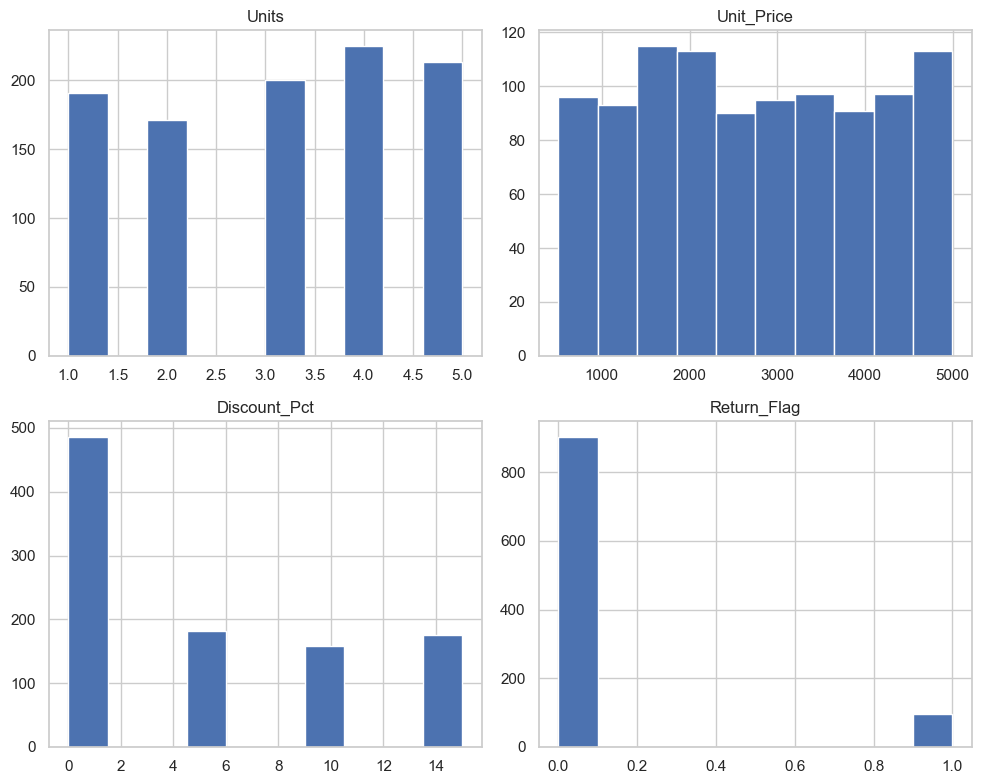

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df.hist(figsize=(10, 8))

plt.tight_layout()
plt.savefig("numeric_distributions.png")
plt.show()

# Correlation Heatmap

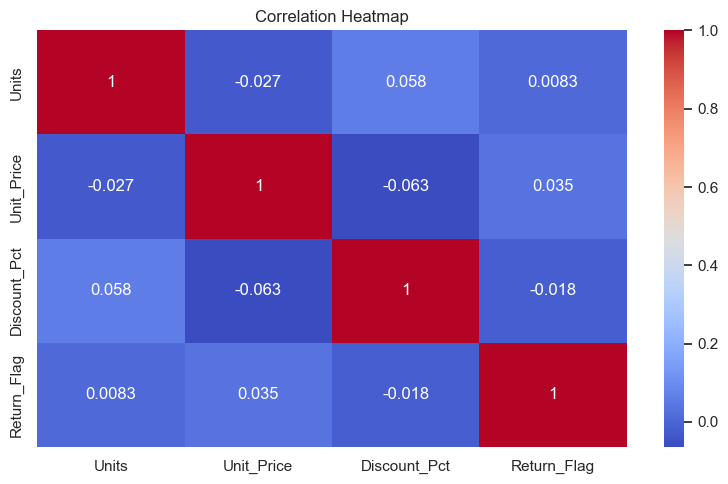

In [3]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    df.select_dtypes("number").corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
plt.show()

# Insight 1 — Category performance

In [4]:
df["Sales"] = df["Units"] * df["Unit_Price"]

df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

Category
Apparel        1263090
Sports         1148471
Beauty         1097306
Home           1054534
Books          1033144
Electronics    1000682
Health          994105
Grocery         864718
Name: Sales, dtype: int64

# Insight 2 — Channel performance

In [5]:
df.groupby("Channel")["Sales"].sum().sort_values(ascending=False)

Channel
Website        2261625
Offline        2172428
Marketplace    2054502
App            1967495
Name: Sales, dtype: int64

Insight 3 — Most active cities

In [6]:
df.groupby("City")["Units"].sum().sort_values(ascending=False).head(10)

City
Pune         432
Jaipur       423
Chennai      420
Bangalore    401
Kolkata      383
Hyderabad    368
Mumbai       359
Delhi        312
Name: Units, dtype: int64

# Insight 4 — Return analysis

In [7]:
df.groupby("Return_Flag")["Units"].sum()

Return_Flag
0    2794
1     304
Name: Units, dtype: int64

# Insight 5 — Discount vs sales

In [8]:
df.groupby("Discount_Pct")["Sales"].sum()

Discount_Pct
0     4075549
5     1553616
10    1350295
15    1476590
Name: Sales, dtype: int64